<a href="https://colab.research.google.com/github/sagartirlapur/ai-pm-portfolio/blob/main/project1-decision-agent/day1_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Environment confirmed.")
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Ready to build.")

Environment confirmed.
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Ready to build.


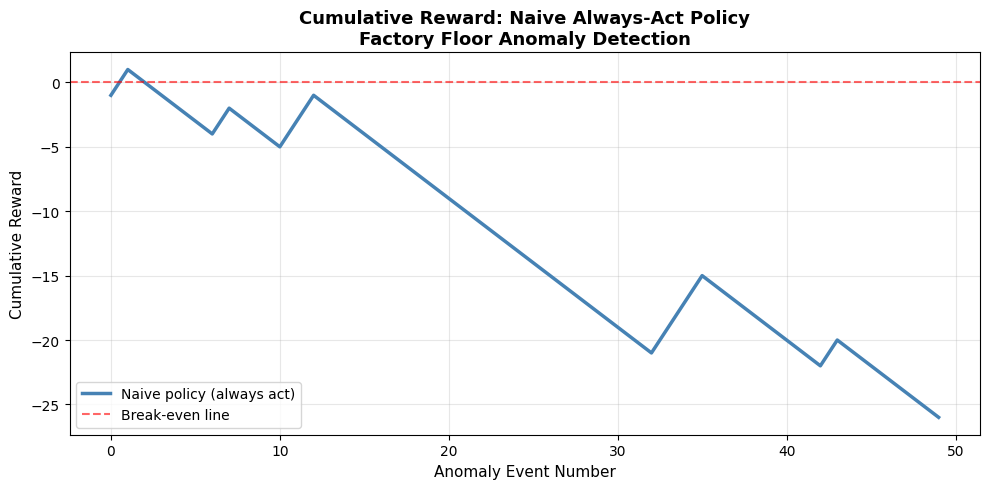

Total decisions: 50
Final cumulative reward: -26
Average reward per decision: -0.52
False alarm rate: 80%


In [ ]:
# ============================================================
# DAY 1: Your First AI Decision System
# Project 1: Counterfactual Decision Agent
# Vertical: Industrial Manufacturing & Predictive Maintenance
# ============================================================
#
# THE SCENARIO:
# A factory floor robot monitors equipment using sensors.
# When it detects an anomaly it must decide:
#
#   ACTION 1 = ACT  → trigger a maintenance call immediately
#   ACTION 0 = WAIT → continue monitoring
#
# THE REWARD STRUCTURE:
# This is one of the most important concepts in all of AI PM work.
# The reward function defines what "good" means for this system.
# Whoever designs the reward function owns the AI's behavior.
# In a product company that person is often the PM.
# Get the reward function wrong and the AI behaves wrong —
# even if every line of code is technically correct.
#
# REWARDS:
#   +2 = acted AND anomaly was real       → correct, valuable
#   -1 = acted BUT it was a false alarm   → costly, wasteful
#    0 = waited                           → neutral, no cost
#
# Notice: we penalise false alarms but not waiting.
# This is a deliberate design choice.
# Change it and the AI's entire behavior changes.
# Remember that — it will come up in every interview.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Setting a random seed makes your results reproducible.
# Every time you run this with seed 42 you get identical results.
# In research and portfolio work reproducibility is non-negotiable.
np.random.seed(42)

# ── PARAMETERS ───────────────────────────────────────────────
n_decisions = 50        # Robot processes 50 anomaly events
true_success_rate = 0.4 # 40% of anomalies are genuine
                        # 60% are false alarms from sensor noise
                        # In a real system a PM validates this with data
                        # This number is your domain knowledge assumption

# ── TRACKING ─────────────────────────────────────────────────
cumulative_reward = 0
rewards_over_time = []

# ── THE DECISION LOOP ─────────────────────────────────────────
# This loop is the heart of every decision system you will build.
# Pattern: observe → decide → receive reward → repeat.
# Later you will add: remember → learn → improve.
# But this core loop never changes across any of the 4 projects.

for step in range(n_decisions):

    # POLICY: the rule the AI uses to choose an action.
    # This is the NAIVE POLICY: always act, no matter what.
    # No intelligence. No learning. Just always trigger maintenance.
    # This is your baseline. Every smarter policy gets compared to this.
    action = 1  # 1 = act, 0 = wait

    # OUTCOME: was the anomaly real?
    # np.random.binomial(1, p) returns 1 with probability p, else 0.
    # This simulates whether the anomaly turned out to be genuine.
    outcome = np.random.binomial(1, true_success_rate)

    # REWARD: what does the AI receive for this decision?
    if action == 1 and outcome == 1:
        reward = 2    # Acted correctly — anomaly was real
    elif action == 1 and outcome == 0:
        reward = -1   # False alarm — wasted maintenance call
    else:
        reward = 0    # Waited — no cost, no gain

    cumulative_reward += reward
    rewards_over_time.append(cumulative_reward)

# ── VISUALISATION ────────────────────────────────────────────
# Rising line = policy is working, gaining value over time.
# Flat line = policy is breaking even.
# Falling line = policy is losing value, costing more than it gains.
# Red dashed line = break-even point.

plt.figure(figsize=(10, 5))
plt.plot(rewards_over_time, color='steelblue', linewidth=2.5,
         label='Naive policy (always act)')
plt.title('Cumulative Reward: Naive Always-Act Policy\n'
          'Factory Floor Anomaly Detection',
          fontsize=13, fontweight='bold')
plt.xlabel('Anomaly Event Number', fontsize=11)
plt.ylabel('Cumulative Reward', fontsize=11)
plt.axhline(y=0, color='red', linestyle='--',
            alpha=0.6, label='Break-even line')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total decisions: {n_decisions}")
print(f"Final cumulative reward: {cumulative_reward}")
print(f"Average reward per decision: {cumulative_reward/n_decisions:.2f}")
print(f"False alarm rate: {1 - true_success_rate:.0%}")

The falling curve shows that the naive always-act policy triggers false alarms 60% of the time, increasing unnecessary maintenance costs and disrupting the production line. A factory manager running this system would be spending money on technicians responding to alerts that do not require action.

**Experiment 1**

Changing the false alarm penalty from -1 to -3 made the curve fall faster and steeper. The AI's behaviour did not change as it was always acting, but teh cost of that behaviour became more visible. This means that the reward function is not just a technical parameter but also a business decision. In a real factory setting this number incorrectly would make a working AI look like a failing one, or hide a failing AI behind forgiving numbers.

In a real scenario, false alarm costs are decided by:
1. Operations manager knows how long a maintenance call would take and costs in labor
2. Finance team knows the cost of production downtime per hour
3. The maintenance team knows the frequency of false alarms from historical logs
4. The PM synthesizes input from all three, grounds the number in real operational data, and owns the decision of what penalty value goes into the reward function before the system is deployed.



**Experiment 2**

**Observation:** When the anomaly rate/true success rate was changed from 40% to 20% the curve fell sharply and the cummulative reward number went from -2 to -26.

**Why it happened:** The naive policy still acts on single anomaly. But now 80% of teh actions are wrong instead of 60%. More wrong actions, same reward and catastrophic results.

**PM Insight:**
The Maintenance team holds the historical incident logs that reveal the true anomaly rate. Before building this system a PM should import 6-12 months of maintenance records, calculate what percentage of triggered alerts resulted in genuine repairs, and validate the number with Operations manager. Deploying an AI without baseline data means building on an assumption. We can see one wrong assumption can result into a costly one.

In [1]:
# ── EXPERIMENT 3: Two policies compared ───────────────────────
# NAIVE:  always act regardless of anything
# SMART:  only act when a confidence score exceeds 0.6
#
# The confidence score here is simulated with a random number.
# In a real system it comes from sensor readings,
# a model's probability output, or a risk scoring system.
#
# THE KEY PM QUESTION inside this experiment:
# Who decides that 0.6 is the right threshold?
# What happens if it is 0.4? Or 0.8?
# That is a product decision disguised as a technical parameter.
# You will own that decision as an AI PM.
# ──────────────────────────────────────────────────────────────

np.random.seed(42)

cumulative_naive = 0
cumulative_smart = 0
rewards_naive = []
rewards_smart = []

for step in range(n_decisions):

    # Both policies face the same anomaly outcome (fair comparison)
    outcome = np.random.binomial(1, true_success_rate)

    # NAIVE POLICY
    action_naive = 1
    if action_naive == 1 and outcome == 1:
        reward_naive = 2
    elif action_naive == 1 and outcome == 0:
        reward_naive = -1
    else:
        reward_naive = 0
    cumulative_naive += reward_naive
    rewards_naive.append(cumulative_naive)

    # SMART POLICY
    # Simulate a confidence score for this anomaly
    confidence = np.random.uniform(0, 1)
    action_smart = 1 if confidence > 0.8 else 0
    if action_smart == 1 and outcome == 1:
        reward_smart = 2
    elif action_smart == 1 and outcome == 0:
        reward_smart = -1
    else:
        reward_smart = 0
    cumulative_smart += reward_smart
    rewards_smart.append(cumulative_smart)

# ── PLOT ─────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(rewards_naive, color='steelblue', linewidth=2.5,
         linestyle='--', label='Naive policy (always act)')
plt.plot(rewards_smart, color='green', linewidth=2.5,
         label='Smart policy (act only if confidence > 0.6)')
plt.title('Naive vs. Smart Policy: Cumulative Reward Comparison\n'
          'Factory Floor Anomaly Detection',
          fontsize=13, fontweight='bold')
plt.xlabel('Anomaly Event Number', fontsize=11)
plt.ylabel('Cumulative Reward', fontsize=11)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── RESULTS ──────────────────────────────────────────────────
difference = rewards_smart[-1] - rewards_naive[-1]
print(f"Naive final reward:   {rewards_naive[-1]}")
print(f"Smart final reward:   {rewards_smart[-1]}")
print(f"Difference:           {difference}")
print()
if difference > 0:
    print("Smart policy won. Being selective about when to act paid off.")
elif difference < 0:
    print("Naive policy won. Waiting too often missed real anomalies.")
else:
    print("Tied.")

NameError: name 'np' is not defined